# Experiment Plotter

In [16]:
import pandas as pd
import numpy as np
from scipy import constants

## Unpack Data

In [2]:
df = pd.read_csv('/Users/omalleysherlock/Developer/OFDM-Sense/experiments/delay_experiment.csv')

actual_distance = df['actual distance(m)']

calculated_delay = df['calculated delay(ns)']

distance0 = df['calculated distance(m)']

# Experiment 2

In [10]:
df = pd.read_csv('/Users/omalleysherlock/Developer/OFDM-Sense/experiments/no_ref_2rx.csv')

delay0 = df['delay0']
distance0 = df['distance0']

delay1 = df['delay1']
distance1 = df['distance1']


actual_distance = np.linspace(110, 50, len(delay0))


# Calculate Angle

In [21]:
d = 0.1 #Distance between RX modules
C = constants.c
for i in range(len(delay0)):
    delta_t = (delay0[i] * 1e-9) - (delay1[i] * 1e-9)
    val = (delta_t * C) / d
    print(val)
    theta = np.arcsin((delta_t * C)/ d)
    print(theta)


15.889000274014524
nan
7.195018991975147
nan
7.494811449996119
nan
9.293566198000063
nan
7.494811449996119
nan
13.190868152028923
nan
10.792528487983034
nan
11.691905862005322
nan
12.591283236027607
nan
11.392113403984348
nan
10.19294357202235
nan
11.991698320026293
nan
8.99377374001972
nan
11.991698319985664
nan
12.291490777966008
nan
11.392113403984348
nan
11.092320945963378
nan
8.69398128195812
nan
10.792528488023665
nan
10.792528488023665
nan
8.693981281998747
nan
11.392113404024979
nan
12.291490778047267
nan
11.691905862005322
nan
9.593358655980406
nan
10.49273603000269
nan
10.49273603000269
nan
11.991698320026293
nan
11.991698319985664
nan
9.593358655980406
nan
10.792528488023665
nan
10.19294357202235
nan
11.092320945963378
nan
10.49273603000269
nan
11.092320946004008
nan
10.49273603000269
nan
10.19294357198172
nan
10.792528488023665
nan
11.392113403984348
nan
11.092320945963378
nan
11.991698319985664
nan
13.190868151947665
nan
10.19294357206298
nan
9.893151114042007
nan
11.39211

/var/folders/p7/p_9cgcc968xcbtfbxm8sv95m0000gn/T/ipykernel_66767/1752691345.py:7: RuntimeWarning: invalid value encountered in arcsin
  theta = np.arcsin((delta_t * C)/ d)


## Plot Data 

In [11]:
import matplotlib.pyplot as plt

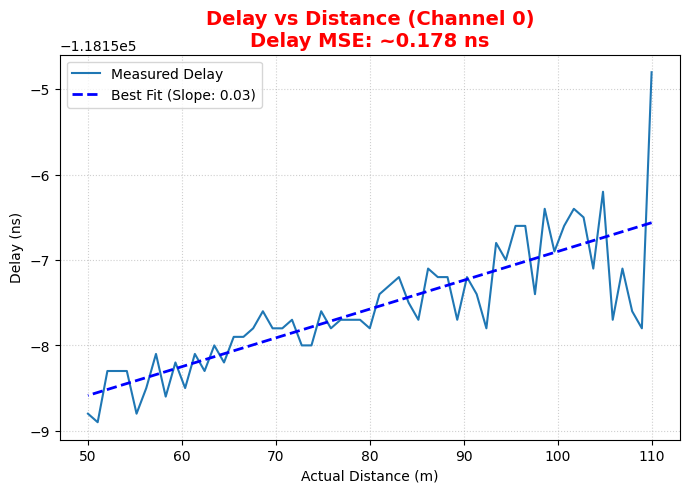

In [14]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_squared_error

# 1. Calculate Line of Best Fit
# This creates the "Predicted" values (line_of_best_fit)
m, b = np.polyfit(actual_distance, delay0, 1)
line_of_best_fit = m * actual_distance + b

# 2. Calculate MSE 
mse = mean_squared_error(delay0, line_of_best_fit)

# 3. Plotting
plt.figure(figsize=(8, 5))

# Original Data
plt.plot(actual_distance, delay0, label='Measured Delay')

# Line of Best Fit
plt.plot(actual_distance, line_of_best_fit, color='blue', linestyle='--', 
         linewidth=2, label=f'Best Fit (Slope: {m:.2f})')

plt.title(f"Delay vs Distance (Channel 0)\nDelay MSE: ~{mse:.3f} ns", fontsize=14, color='red', fontweight='bold')
plt.xlabel("Actual Distance (m)")
plt.ylabel("Delay (ns)")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

plt.show()

# Plot Calced Distance Data

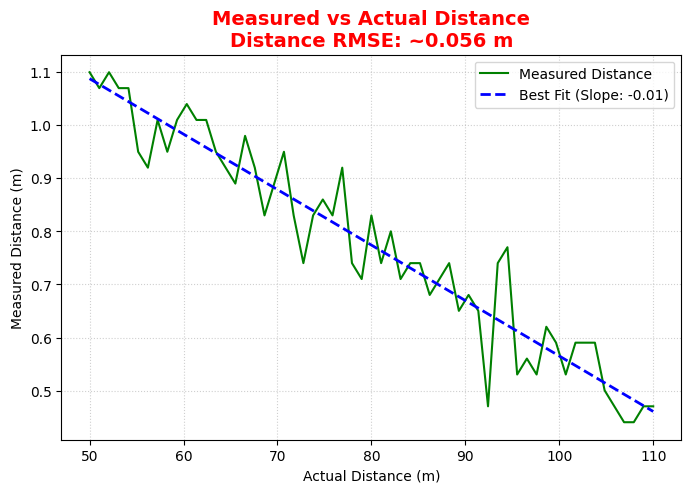

In [8]:
# Calculate Line of Best Fit
m, b = np.polyfit(actual_distance, distance1, 1)
line_of_best_fit = m * actual_distance + b

# Calculate MSE and then RMSE
mse = mean_squared_error(distance1, line_of_best_fit)
rmse = np.sqrt(mse)  # Convert to meters

# Plotting
plt.figure(figsize=(8, 5))

# Original Data
plt.plot(actual_distance, distance1, color='green', label='Measured Distance')

# Line of Best Fit
plt.plot(actual_distance, line_of_best_fit, color='blue', linestyle='--', 
         linewidth=2, label=f'Best Fit (Slope: {m:.2f})')

# UPDATED: Title says "Distance" and uses RMSE for "m" units
plt.title(f"Measured vs Actual Distance\nDistance RMSE: ~{rmse:.3f} m", fontsize=14, color='red', fontweight='bold')

plt.xlabel("Actual Distance (m)")
plt.ylabel("Measured Distance (m)")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

plt.show()

# 